<a href="https://colab.research.google.com/github/fahad15fede/SMIT-ANN_ASSIGNMENTS/blob/main/Loan_Approval_Prediction_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loan Approval Prediction - ANN

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('loan_approval_dataset.csv')

## Loading Dataset


In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


## Data Preprocessing


In [ ]:
df.isna().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [ ]:
df[' no_of_dependents'].unique()

array([2, 0, 3, 5, 4, 1])

In [ ]:
df[' self_employed'].unique()

array([' No', ' Yes'], dtype=object)

In [ ]:
df[' education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [ ]:
df[' loan_term'].unique()

array([12,  8, 20, 10,  4,  2, 18, 16, 14,  6])

In [ ]:
df[' loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [ ]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
for col in df.select_dtypes(include="object").columns:
  df[col] = df[col].str.strip().str.lower()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


## Encoding categorical features

In [ ]:
df['education'] = df['education'].map({
    "graduate": 1,
    "not graduate": 0
})

df['self_employed'] = df['self_employed'].map({
    "yes": 1,
    "no": 0
})

In [ ]:
df['education'].unique()

array([1, 0])

In [ ]:
df['self_employed'].unique()

array([0, 1])

In [ ]:
df['loan_status'] = df['loan_status'].map({
    "approved": 1,
    "rejected": 0
})

In [ ]:
df['loan_status'].unique()

array([1, 0])

## Defining Input features (X) and target variable (y)

In [ ]:
X = df.drop(['loan_status', 'loan_id'], axis=1)
y = df['loan_status']

## Applying Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled.astype("float32")

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Building ANN (Artificial Neural Network) architecture

In [ ]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],))),
model.add(Dense(16, activation="relu")),
model.add(Dense(8, activation="relu")),
model.add(Dense(1, activation="sigmoid"))


## Compiling Model and Training

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32
)

Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9669 - loss: 0.0920 - val_accuracy: 0.9520 - val_loss: 0.0980
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9678 - loss: 0.0894 - val_accuracy: 0.9602 - val_loss: 0.0960
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9695 - loss: 0.0880 - val_accuracy: 0.9590 - val_loss: 0.0937
Epoch 4/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9678 - loss: 0.0864 - val_accuracy: 0.9567 - val_loss: 0.0933
Epoch 5/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9681 - loss: 0.0842 - val_accuracy: 0.9555 - val_loss: 0.0906
Epoch 6/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9719 - loss: 0.0820 - val_accuracy: 0.9578 - val_loss: 0.0913
Epoch 7/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9707 - loss: 0.0818 - val_accuracy: 0.9578 - val_loss: 0.0883
Epoch 8/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9695 - loss: 0.0802 - val_accuracy: 0.

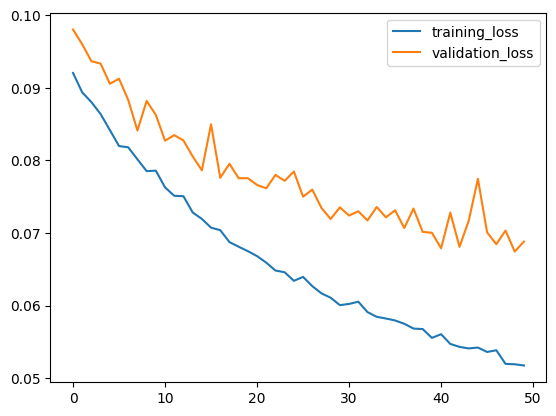

In [ ]:
plt.plot(history.history['loss'], label="training_loss")
plt.plot(history.history['val_loss'], label="validation_loss")
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


## Evaluating Model Performance

In [ ]:
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f'Training Loss: {train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Training Loss: 0.0505, Training Accuracy: 0.9795
Test Loss: 0.0688, Test Accuracy: 0.9719


## Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Generate predictions for the test set
y_pred_test = (model.predict(X_test) > 0.5).astype("int32")

# Print classification report
print("Classification Report for Test Set:")
print(classification_report(y_test, y_pred_test))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Classification Report for Test Set:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       318
           1       0.98      0.98      0.98       536

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

